# Project plasma-cell states in the Bianchi cohort

**Biology rationale.** Cross-cohort program projection evaluates the portability of the plasma-cell state model.

**Aim.** Apply starCAT programs to Bianchi plasma cells and compare program distributions.

**Data input.** `Bianchi.h5ad`, `umap_usage_panels.pdf`, `cnmf_status_cat_annotation.csv`, `UMAP_{group_col}.pdf`



**Data outputs.** `../cNMF_withoutIG_k=13/plasma_cNMF_3_withoutIG_k=13/plasma_cNMF_3_withoutIG_k=13.starcat_spectra.k_13.dt_2_0.txt`, `plasma_cnmf_3_usage_norm_withoutIG_k=13_allplasmacell.csv`, `{score_col}_{group_col}_sample_level_pairwise_stats.csv`, `{score_col}_boxplot_{group_col}_with_stats.pdf`, `{score_col}_boxplot_{group_col}_with_stats.png`

## 1. Packages and setup


In [1]:
import sys
from cnmf import cNMF
import os
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from starcat import starCAT



In [2]:
tcat = starCAT(reference='../cNMF_withoutIG_k=13/plasma_cNMF_3_withoutIG_k=13/plasma_cNMF_3_withoutIG_k=13.starcat_spectra.k_13.dt_2_0.txt', 
               cachedir='./query_cNMF/cache')


Using user specified reference spectra file ../cNMF_withoutIG_k=13/plasma_cNMF_3_withoutIG_k=13/plasma_cNMF_3_withoutIG_k=13.starcat_spectra.k_13.dt_2_0.txt
No scores provided


In [3]:
tcat.ref

,PERM1,ISG15,TTLL10,TNFRSF18,TNFRSF4,TAS1R3,TMEM52,MMEL1,AL512413.1,MEGF6,...,AMELY,TBL1Y,AC064829.1,AC244213.1,AC004556.3,AC233755.2,AC233755.1,AC136616.3,AC136616.2,AC141272.1
GEP1,0.000000,0.605092,0.000000,0.000000,0.000000,0.112493,0.000000,0.000000,0.001787,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
GEP2,0.046746,0.426410,0.000000,0.354571,0.360851,0.623126,0.449011,0.029182,0.000000,0.054676,...,0.000000,0.000000,0.000000,0.022139,0.214174,0.000000,0.230403,0.091618,0.310233,0.481726
GEP3,0.000000,0.377933,0.006809,0.508294,0.397441,0.169179,0.006413,0.000000,0.000000,0.040408,...,0.098393,0.080297,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
GEP4,0.000000,0.002521,0.000000,1.113971,0.975821,0.000000,0.000000,0.000000,0.001403,0.022440,...,0.000000,0.000000,0.059156,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
GEP5,0.055977,0.834073,0.052521,0.239575,0.298272,0.000000,0.384284,0.009218,0.000000,0.103687,...,0.014648,0.000000,0.000000,0.925469,0.288303,0.000000,3.531507,0.000000,0.000000,0.000000
GEP6,0.003823,0.115977,0.000000,0.124212,0.261377,0.830904,0.446456,0.004871,0.045169,0.005919,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.004694,0.000000,0.000000
GEP7,0.000000,0.142833,0.000000,0.679429,0.739847,0.038123,0.000000,0.002912,0.000000,0.001585,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
GEP8,0.000000,0.000000,0.000000,0.000000,0.000000,0.272512,0.122547,0.011927,0.000000,0.001070,...,0.044460,0.210256,0.000000,0.000000,0.161448,5.954403,0.000000,0.000000,0.000000,0.007968
GEP9,0.000000,0.649994,0.000000,0.000000,0.071790,0.000000,0.000000,0.202136,0.000000,0.136788,...,0.000000,0.000000,0.000000,0.005475,0.031971,0.000000,0.000000,0.000000,0.000000,0.000000
GEP10,0.000000,0.243783,0.000000,0.056349,0.142326,0.100253,0.000000,0.000000,0.000000,0.145105,...,0.000000,0.000000,0.000000,0.000000,0.173782,0.000000,0.000000,0.000000,0.005580,0.018929


In [4]:
adata = sc.read_h5ad("Bianchi.h5ad")

In [5]:
# Run starCAT 
usage, _ = tcat.fit_transform(adata)


1571 out of 2000 genes in the reference overlap with the query


/home/miniconda3/envs/cassiopeia/lib/python3.8/site-packages/starcat/starcat.py:244: UserWarning: WARNING!: query input is not an integer count matrix as expected.
            Please provide an integer count matrix unless you are sure you know what you are doing.
  warnings.warn("""WARNING!: query input is not an integer count matrix as expected.
/home/miniconda3/envs/cassiopeia/lib/python3.8/site-packages/starcat/starcat.py:253: UserWarning: WARNING!: query input has 648 genes with 0 counts after overlapping with query. Normalized values for these genes are set to 0.
  warnings.warn("""WARNING!: query input has %d genes with 0 counts after overlapping with query. Normalized values for these genes are set to 0.""" % num_zeros, UserWarning)


## 2. Sample metadata and clinical groups


In [6]:
usage.head()

,GEP1,GEP2,GEP3,GEP4,GEP5,GEP6,GEP7,GEP8,GEP9,GEP10,GEP11,GEP12,GEP13
HDneg_HDneg-CAGCTAAGTCATATCG,2.716371e-08,5.663096e-01,0.219610,0.203385,1.042023e-30,1.217340e-08,0.001150,7.729493e-17,5.881252e-17,1.856874e-09,0.007192,1.006796e-07,0.002354
HDneg_HDneg-CGTGTCTTCACAACGT,2.885520e-02,1.688029e-01,0.000183,0.160905,1.340546e-12,3.582099e-01,0.221711,5.786767e-02,1.949764e-03,3.234080e-07,0.000003,8.488768e-04,0.000664
HDneg_HDneg-CTAATGGCATCGATTG,3.124323e-01,1.409732e-01,0.145627,0.332946,2.089141e-02,1.397172e-11,0.008724,2.619928e-02,1.334081e-06,1.249181e-05,0.007613,3.295956e-06,0.004577
HDneg_HDneg-GCCTCTACAGCATACT,1.781955e-01,1.427647e-01,0.449519,0.025513,1.351122e-01,1.474728e-06,0.000164,5.739793e-04,5.661491e-03,3.108457e-03,0.041156,5.631003e-03,0.012600
HDneg_HDneg-TCAGGATTCTCCAGGG,1.264181e-01,9.464160e-07,0.300954,0.022418,1.349504e-01,2.166387e-01,0.010253,1.297919e-01,9.782406e-05,3.552938e-02,0.006662,8.620626e-03,0.007665


In [7]:
adata

AnnData object with n_obs × n_vars = 8789 × 25111
    obs: 'nCount_RNA', 'nFeature_RNA', 'sample_id_raw', 'cell_id_raw_counts', 'sample_id_from_cell_id', 'sample_id_for_matching', 'barcode_core_from_counts', 'sample_group_inferred', 'disease_inferred', 'CD138_fraction_inferred', 'meta_cell_id_metadata', 'meta_library_name', 'donor_id_global', 'condition', 'PC_subset', 'projected_CellType', 'cell_annotation_from_metadata', 'CD138_fraction', 'metadata_source_file', 'CD138_fraction_final', 'condition_final', 'cell_annotation_final', 'percent.mt', 'RNA_snn_res.0.5', 'seurat_clusters', 'n_bcr_chains', 'n_bcr_loci', 'bcr_loci', 'bcr_cdr3_aa', 'bcr_v_call', 'bcr_d_call', 'bcr_j_call', 'bcr_c_call', 'bcr_total_umi', 'bcr_max_umi', 'bcr_files', 'bcr_cdr3_norm', 'clonotype', 'bcr_clone_size', 'bcr_clone_n_cdr3_signatures', 'bcr_clone_representative_cdr3'
    var: 'vf_vst_counts.1_mean', 'vf_vst_counts.1_variance', 'vf_vst_counts.1_variance.expected', 'vf_vst_counts.1_variance.standardized', 'vf_

In [8]:
# Merge usages and scores with cell metadata
adata.obs = pd.merge(left=adata.obs, right=usage, how='left', left_index=True, right_index=True)


## 3. Gene-expression program analysis


In [9]:
adata

AnnData object with n_obs × n_vars = 8789 × 25111
    obs: 'nCount_RNA', 'nFeature_RNA', 'sample_id_raw', 'cell_id_raw_counts', 'sample_id_from_cell_id', 'sample_id_for_matching', 'barcode_core_from_counts', 'sample_group_inferred', 'disease_inferred', 'CD138_fraction_inferred', 'meta_cell_id_metadata', 'meta_library_name', 'donor_id_global', 'condition', 'PC_subset', 'projected_CellType', 'cell_annotation_from_metadata', 'CD138_fraction', 'metadata_source_file', 'CD138_fraction_final', 'condition_final', 'cell_annotation_final', 'percent.mt', 'RNA_snn_res.0.5', 'seurat_clusters', 'n_bcr_chains', 'n_bcr_loci', 'bcr_loci', 'bcr_cdr3_aa', 'bcr_v_call', 'bcr_d_call', 'bcr_j_call', 'bcr_c_call', 'bcr_total_umi', 'bcr_max_umi', 'bcr_files', 'bcr_cdr3_norm', 'clonotype', 'bcr_clone_size', 'bcr_clone_n_cdr3_signatures', 'bcr_clone_representative_cdr3', 'GEP1', 'GEP2', 'GEP3', 'GEP4', 'GEP5', 'GEP6', 'GEP7', 'GEP8', 'GEP9', 'GEP10', 'GEP11', 'GEP12', 'GEP13'
    var: 'vf_vst_counts.1_mean', 'v

First we plot the discrete features output by starCAT

As well as continuous scores

And we can output the continuous usages of all of the cGEPs

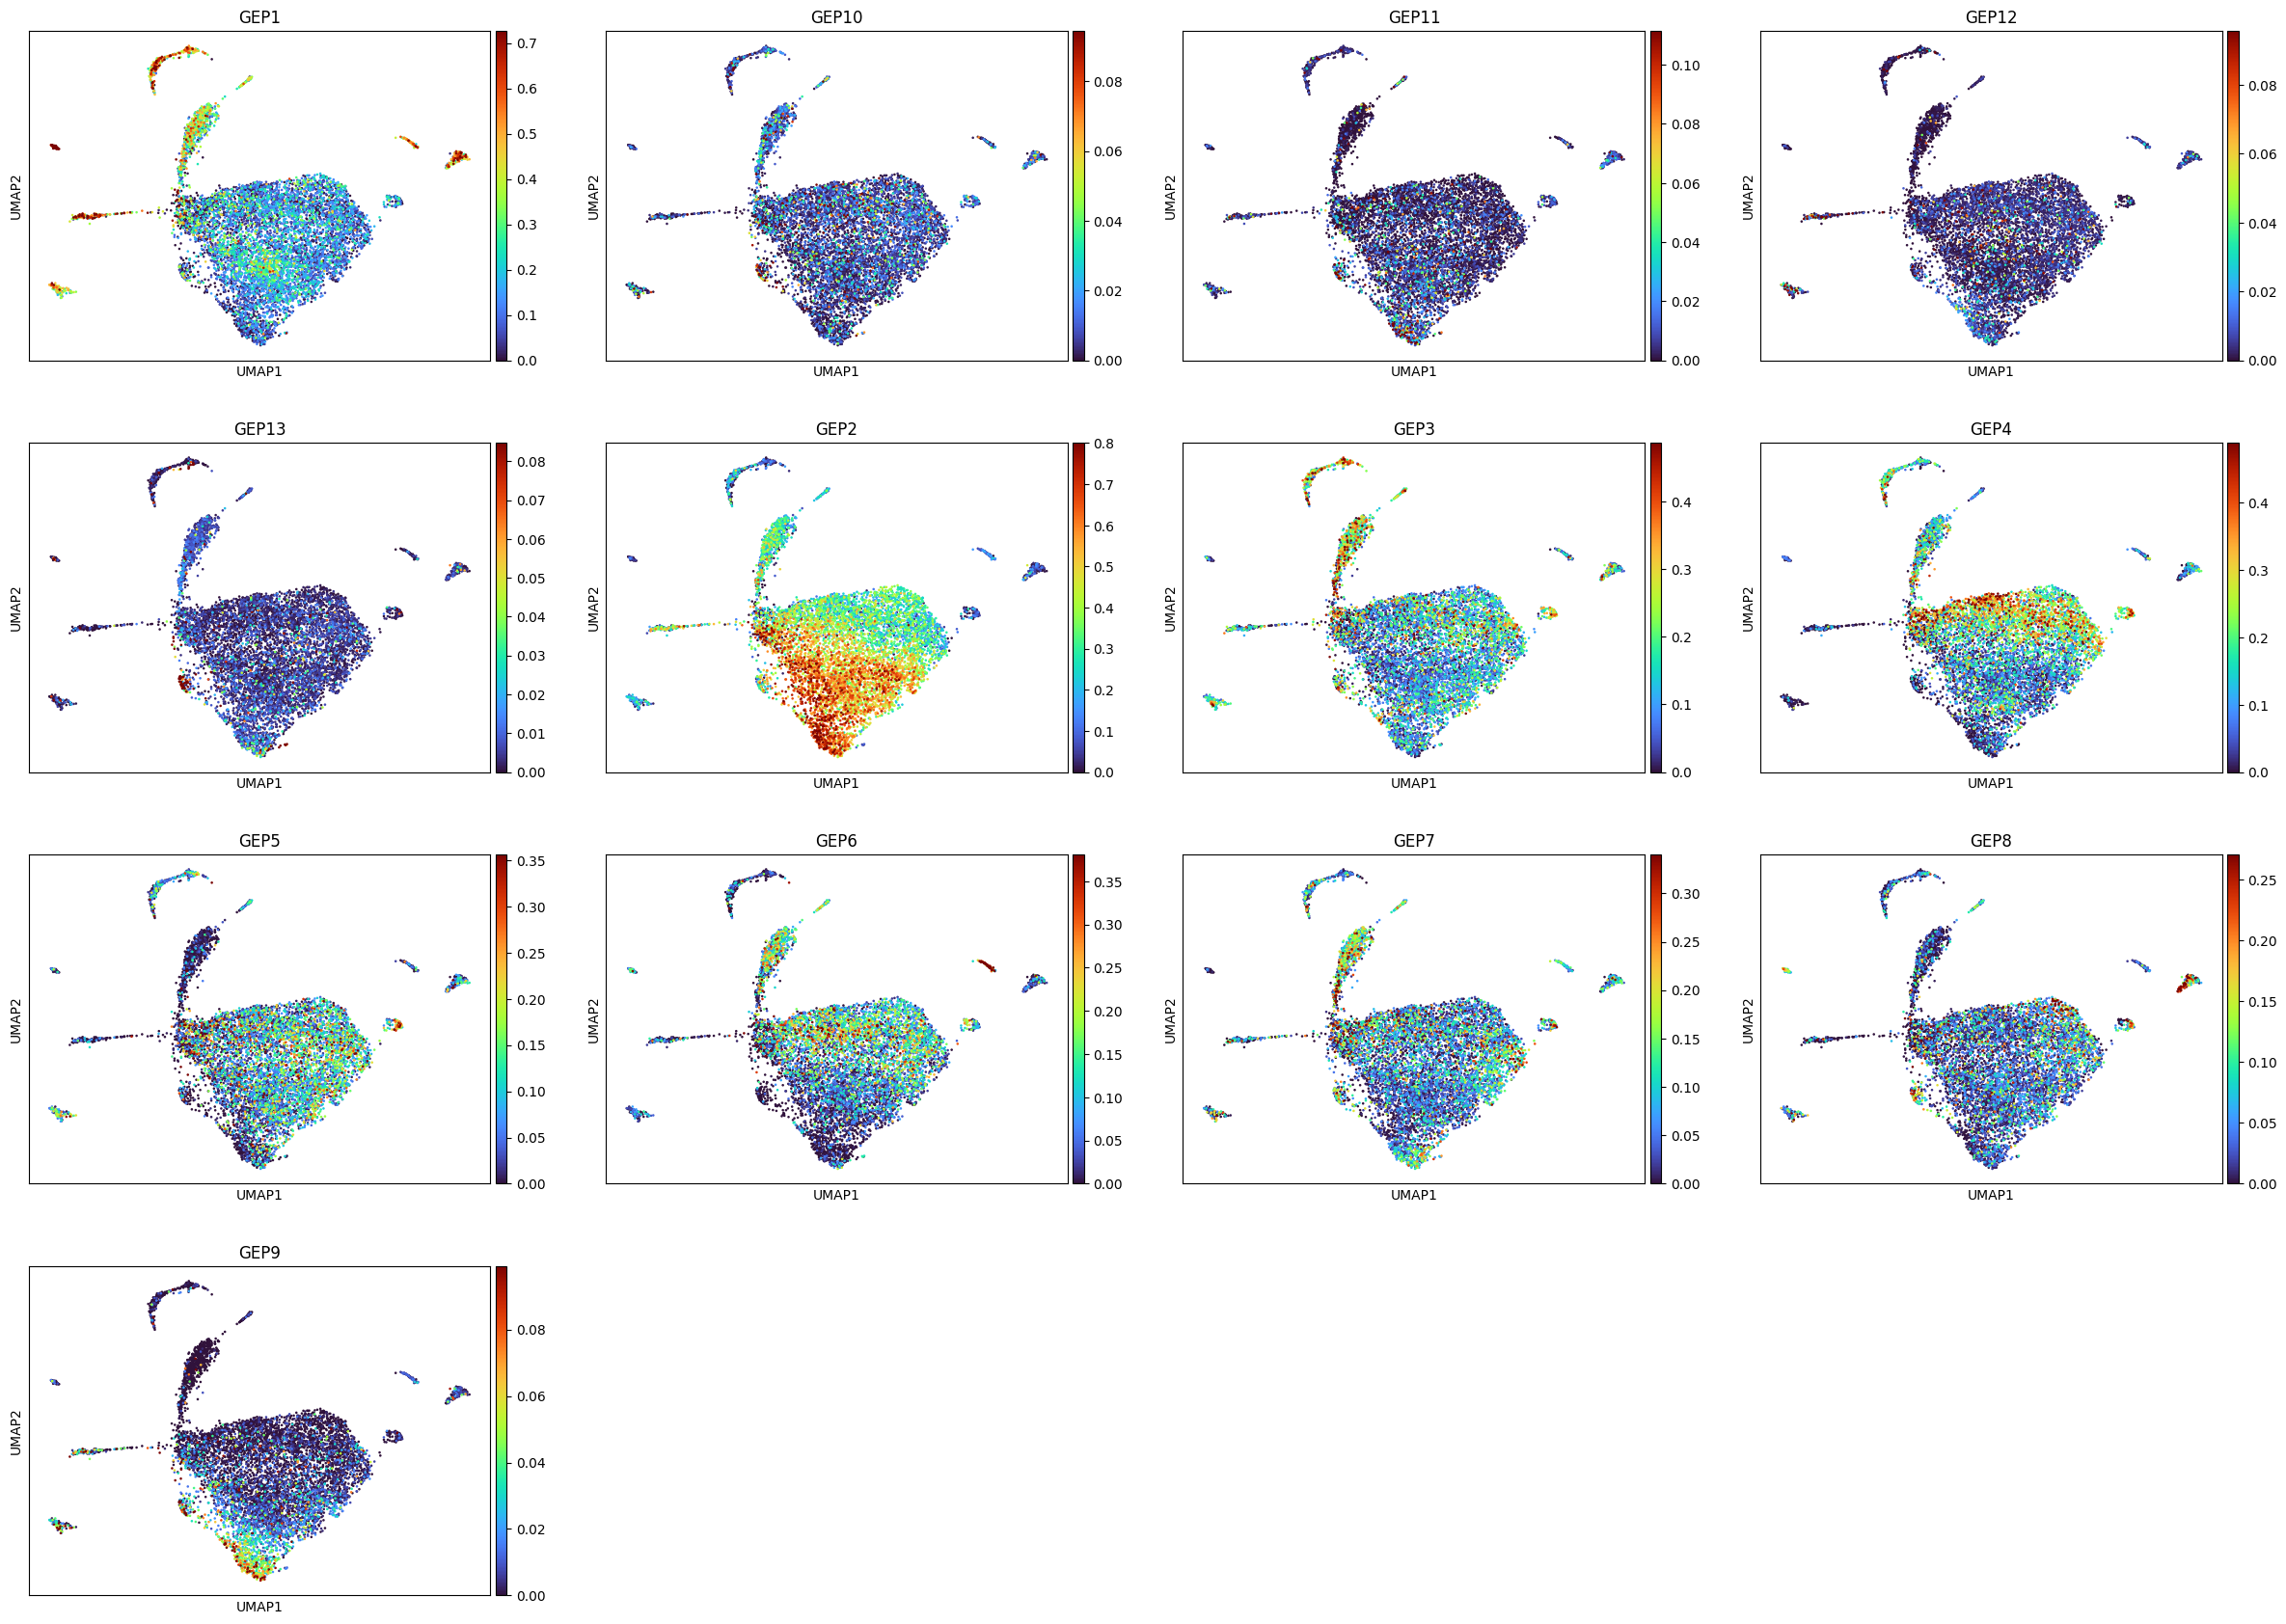

In [10]:
sc.pl.umap(adata, color=sorted(usage.columns), ncols=4, vmin=0, vmax='p99',color_map="turbo")

In [11]:
import math
import scanpy as sc
import matplotlib.pyplot as plt

# --- inputs ---
features = sorted(usage.columns)
ncols = 4
nrows = math.ceil(len(features) / ncols)

# --- make each panel more "square" by controlling inches per panel ---
panel_size = 3.2  # tune this (e.g., 2.8-4.0)
figsize = (panel_size * ncols, panel_size * nrows)

# Option A (recommended): set scanpy global figure params (works in older versions)
sc.set_figure_params(figsize=figsize)

# (Optional) tighten spacing between panels a bit
hspace = 0.35
wspace = 0.25

# --- plot (no figsize argument here) ---
sc.pl.umap(
    adata,
    color=features,
    ncols=ncols,
    vmin=0,
    vmax="p99",
    color_map="turbo",
    show=False,
    hspace=hspace,
    wspace=wspace,
)

# --- save to PDF ---
out_pdf = "umap_usage_panels.pdf"
plt.savefig(out_pdf, bbox_inches="tight")
plt.close()
print(f"Saved: {out_pdf}")


Saved: umap_usage_panels.pdf


In [12]:
import numpy as np
import pandas as pd

# --- choose the CNMF usage columns of interest ---
use_cols = ["GEP1", "GEP2", "GEP3", "GEP4", "GEP6", "GEP7", "GEP8", "GEP9","GEP11"]
present = [c for c in use_cols if c in adata.obs.columns]
if len(present) == 0:
    raise ValueError("None of the required CNMF columns are present in adata.obs")

# Subset and ensure numeric
U = adata.obs[present].apply(pd.to_numeric, errors="coerce")

# Map column name -> status number
status_map = {"GEP1":1, "GEP2":2,"GEP3":3,"GEP4":4,"GEP6":6,"GEP7":7,"GEP8":8, "GEP9":9,"GEP11":11}

# Row-wise argmax to pick the dominant component
argmax_idx = U.values.argmax(axis=1)  # returns positional index among `present`
chosen_cols = [present[i] if np.isfinite(i) else np.nan for i in argmax_idx]

# Convert chosen column names to status numbers; NaN if all four are NaN
status = []
confidence = []
for i, row in U.iterrows():
    vals = row.values.astype(float)
    if np.all(~np.isfinite(vals)):
        status.append(np.nan)
        confidence.append(np.nan)
        continue
    s = np.nansum(vals)
    m = np.nanmax(vals)
    # chosen column:
    j = np.nanargmax(vals)
    status.append(status_map[present[j]])
    # confidence = max / sum (guard zero/NaN)
    conf = (m / s) if (np.isfinite(m) and np.isfinite(s) and s > 0) else np.nan
    confidence.append(conf)

adata.obs["cnmf_status"] = pd.Series(status, index=U.index).astype("Float64")
adata.obs["cnmf_status_confidence"] = pd.Series(confidence, index=U.index).astype("Float64")

# Optional: mark low-confidence as unclassified (commented out)
# THRESH = 0.4
# mask_low = adata.obs["cnmf_status_confidence"].fillna(0) < THRESH
# adata.obs.loc[mask_low, "cnmf_status"] = pd.NA

# Make a categorical for nicer plotting (keeps numeric labels as strings)
adata.obs["cnmf_status_cat"] = (
    adata.obs["cnmf_status"]
    .astype("Int64")
    .astype(str)
    .replace({"<NA>": "NA"})
    .astype("category")
)

print(
    "Assigned cnmf_status to "
    f"{adata.obs['cnmf_status'].notna().sum()} / {adata.n_obs} cells.\n"
    "Value counts:\n",
    adata.obs["cnmf_status_cat"].value_counts(dropna=False)
)


Assigned cnmf_status to 8788 / 8789 cells.
Value counts:
 cnmf_status_cat
2     5428
1     1358
4      902
3      562
6      271
7      154
8       83
11      19
9       11
NA       1
Name: count, dtype: int64


/home/miniconda3/envs/cassiopeia/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: title={'center': 'cnmf_status_cat'}, xlabel='UMAP1', ylabel='UMAP2'>

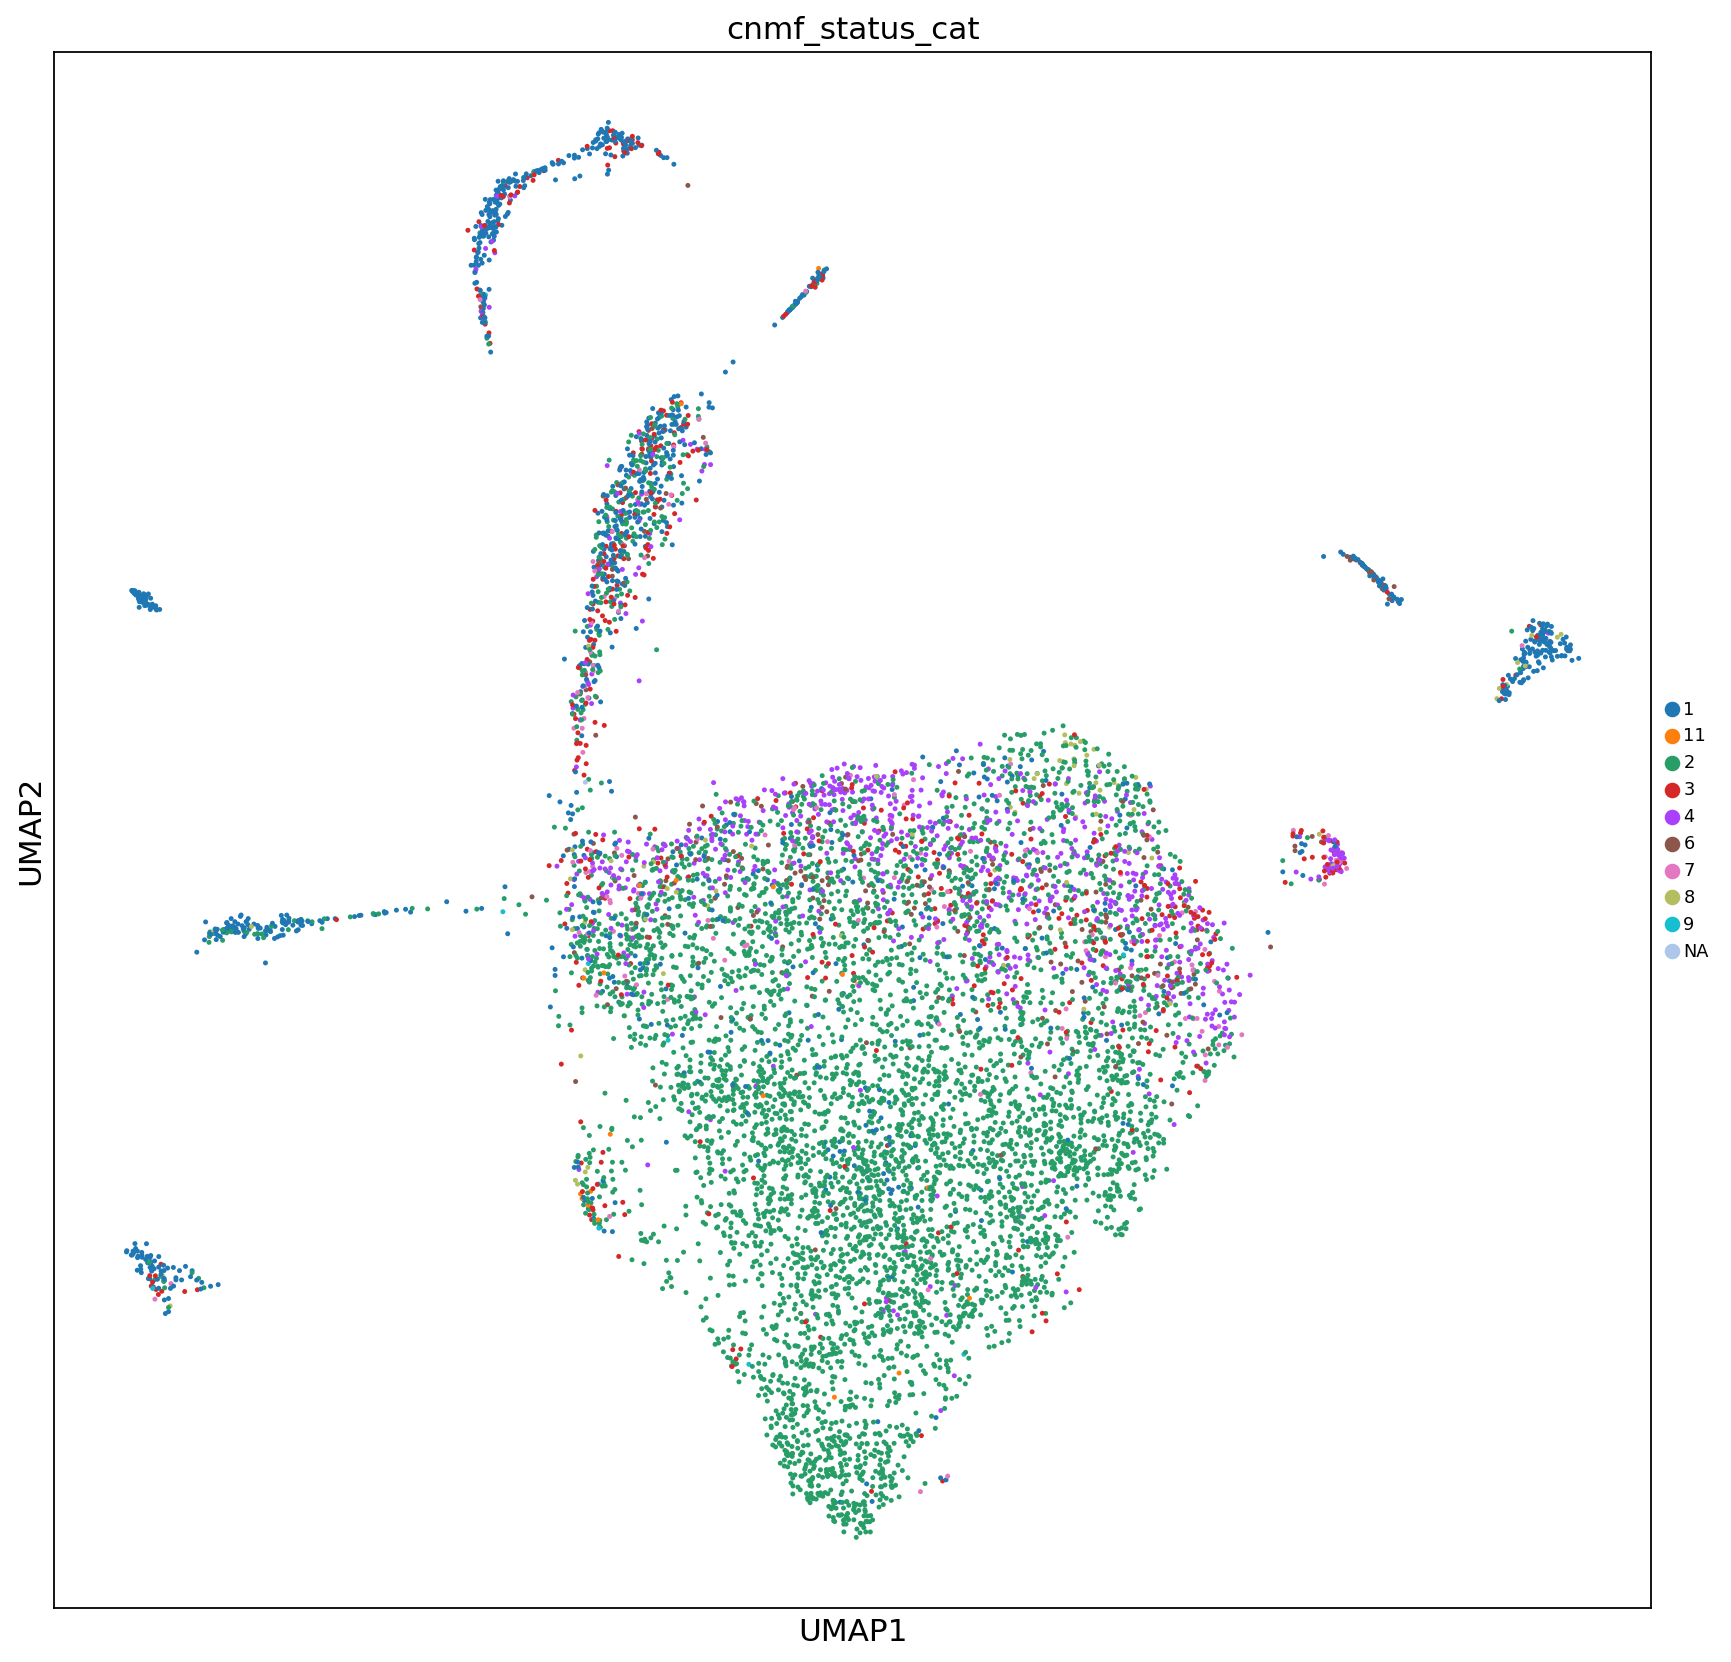

In [19]:

# --- Figure layout (2 panels side by side)
ncols = 2
nrows = 1
figsize = 5
wspace = 0.5

sc.pl.umap(
    adata,
    color=["cnmf_status_cat"],
    show=False,
    legend_loc="right margin",   # move legend outside to save space
    legend_fontsize=8,
    size=20,
    wspace=0.3,
)


## 4. Gene-expression program analysis


In [14]:
usage_norm = adata.obs[use_cols]

In [15]:
usage_norm.to_csv("plasma_cnmf_3_usage_norm_withoutIG_k=13_allplasmacell.csv", index=True)

In [16]:
import pandas as pd

# pick the source AnnData and the column you want to transfer
src = adata
col = "cnmf_status_cat"

# export with cell barcodes (obs_names) as the key
out_csv = "cnmf_status_cat_annotation.csv"
src.obs[[col]].to_csv(out_csv, index=True)  # index=True keeps barcodes

print("Saved:", out_csv, "rows:", src.n_obs)


Saved: cnmf_status_cat_annotation.csv rows: 8789


## 5. Visualization and figure generation


/home/miniconda3/envs/cassiopeia/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: title={'center': 'donor_id_global'}, xlabel='UMAP1', ylabel='UMAP2'>

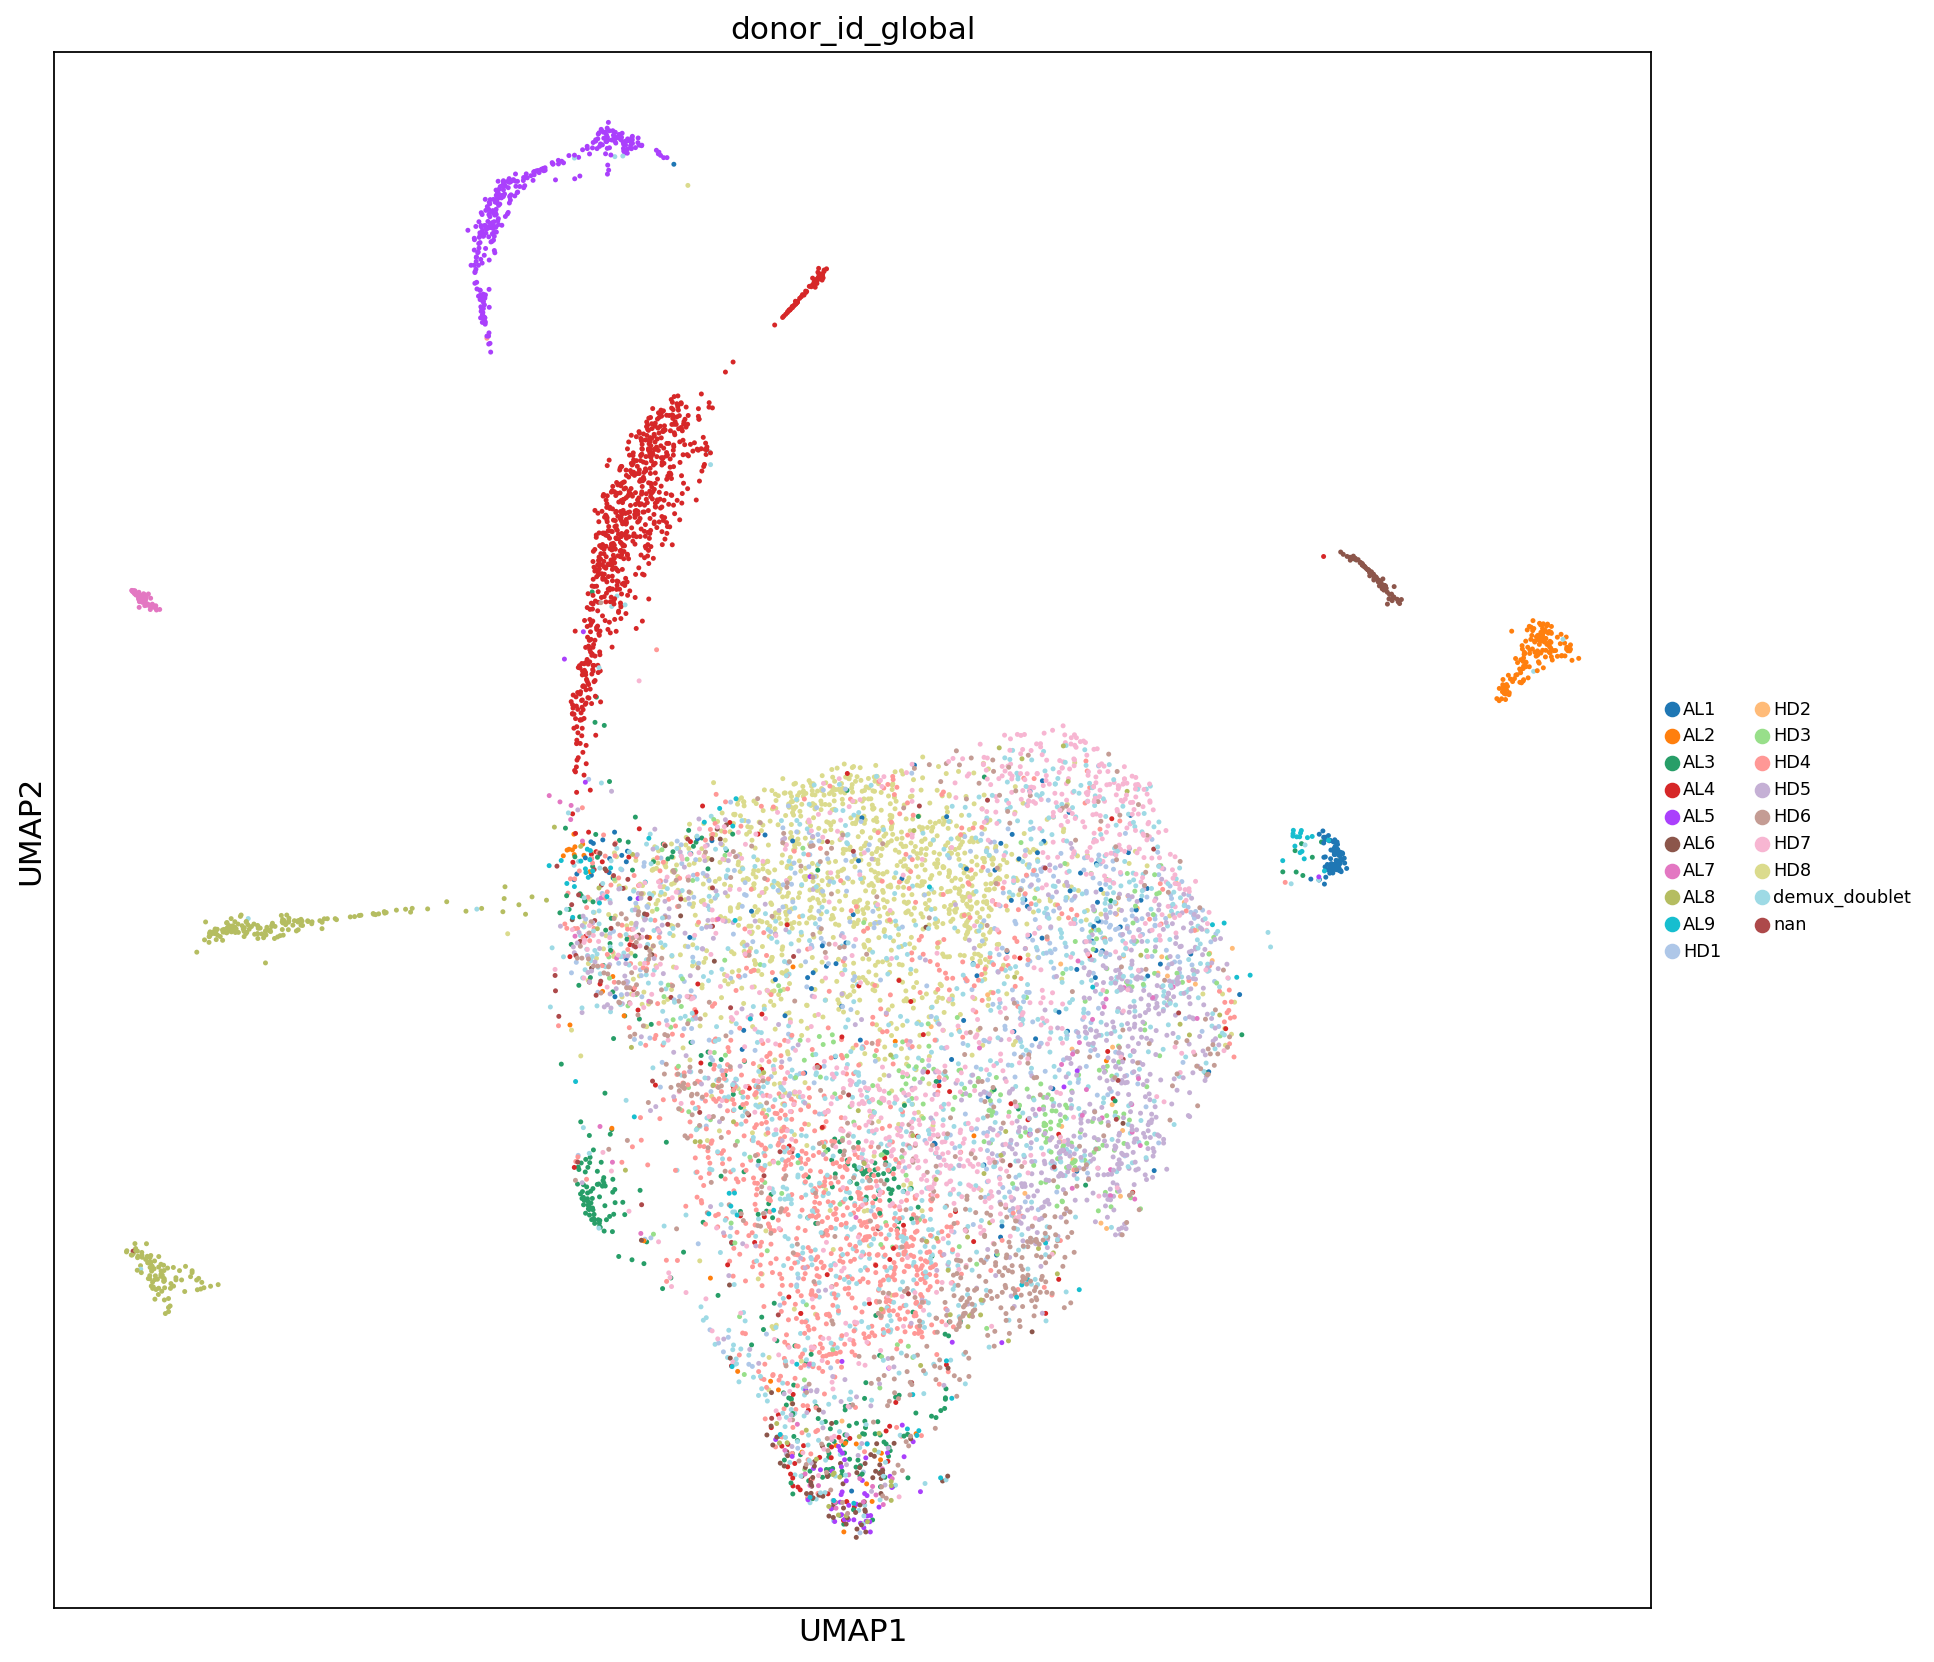

In [20]:
sc.pl.umap(
    adata,
    color=["donor_id_global"],
    show=False,
    legend_loc="right margin",   # move legend outside to save space
    legend_fontsize=8,
    size=20,
    wspace=0.3,
)


/home/miniconda3/envs/cassiopeia/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: title={'center': 'orig_ident_N_status'}, xlabel='UMAP1', ylabel='UMAP2'>

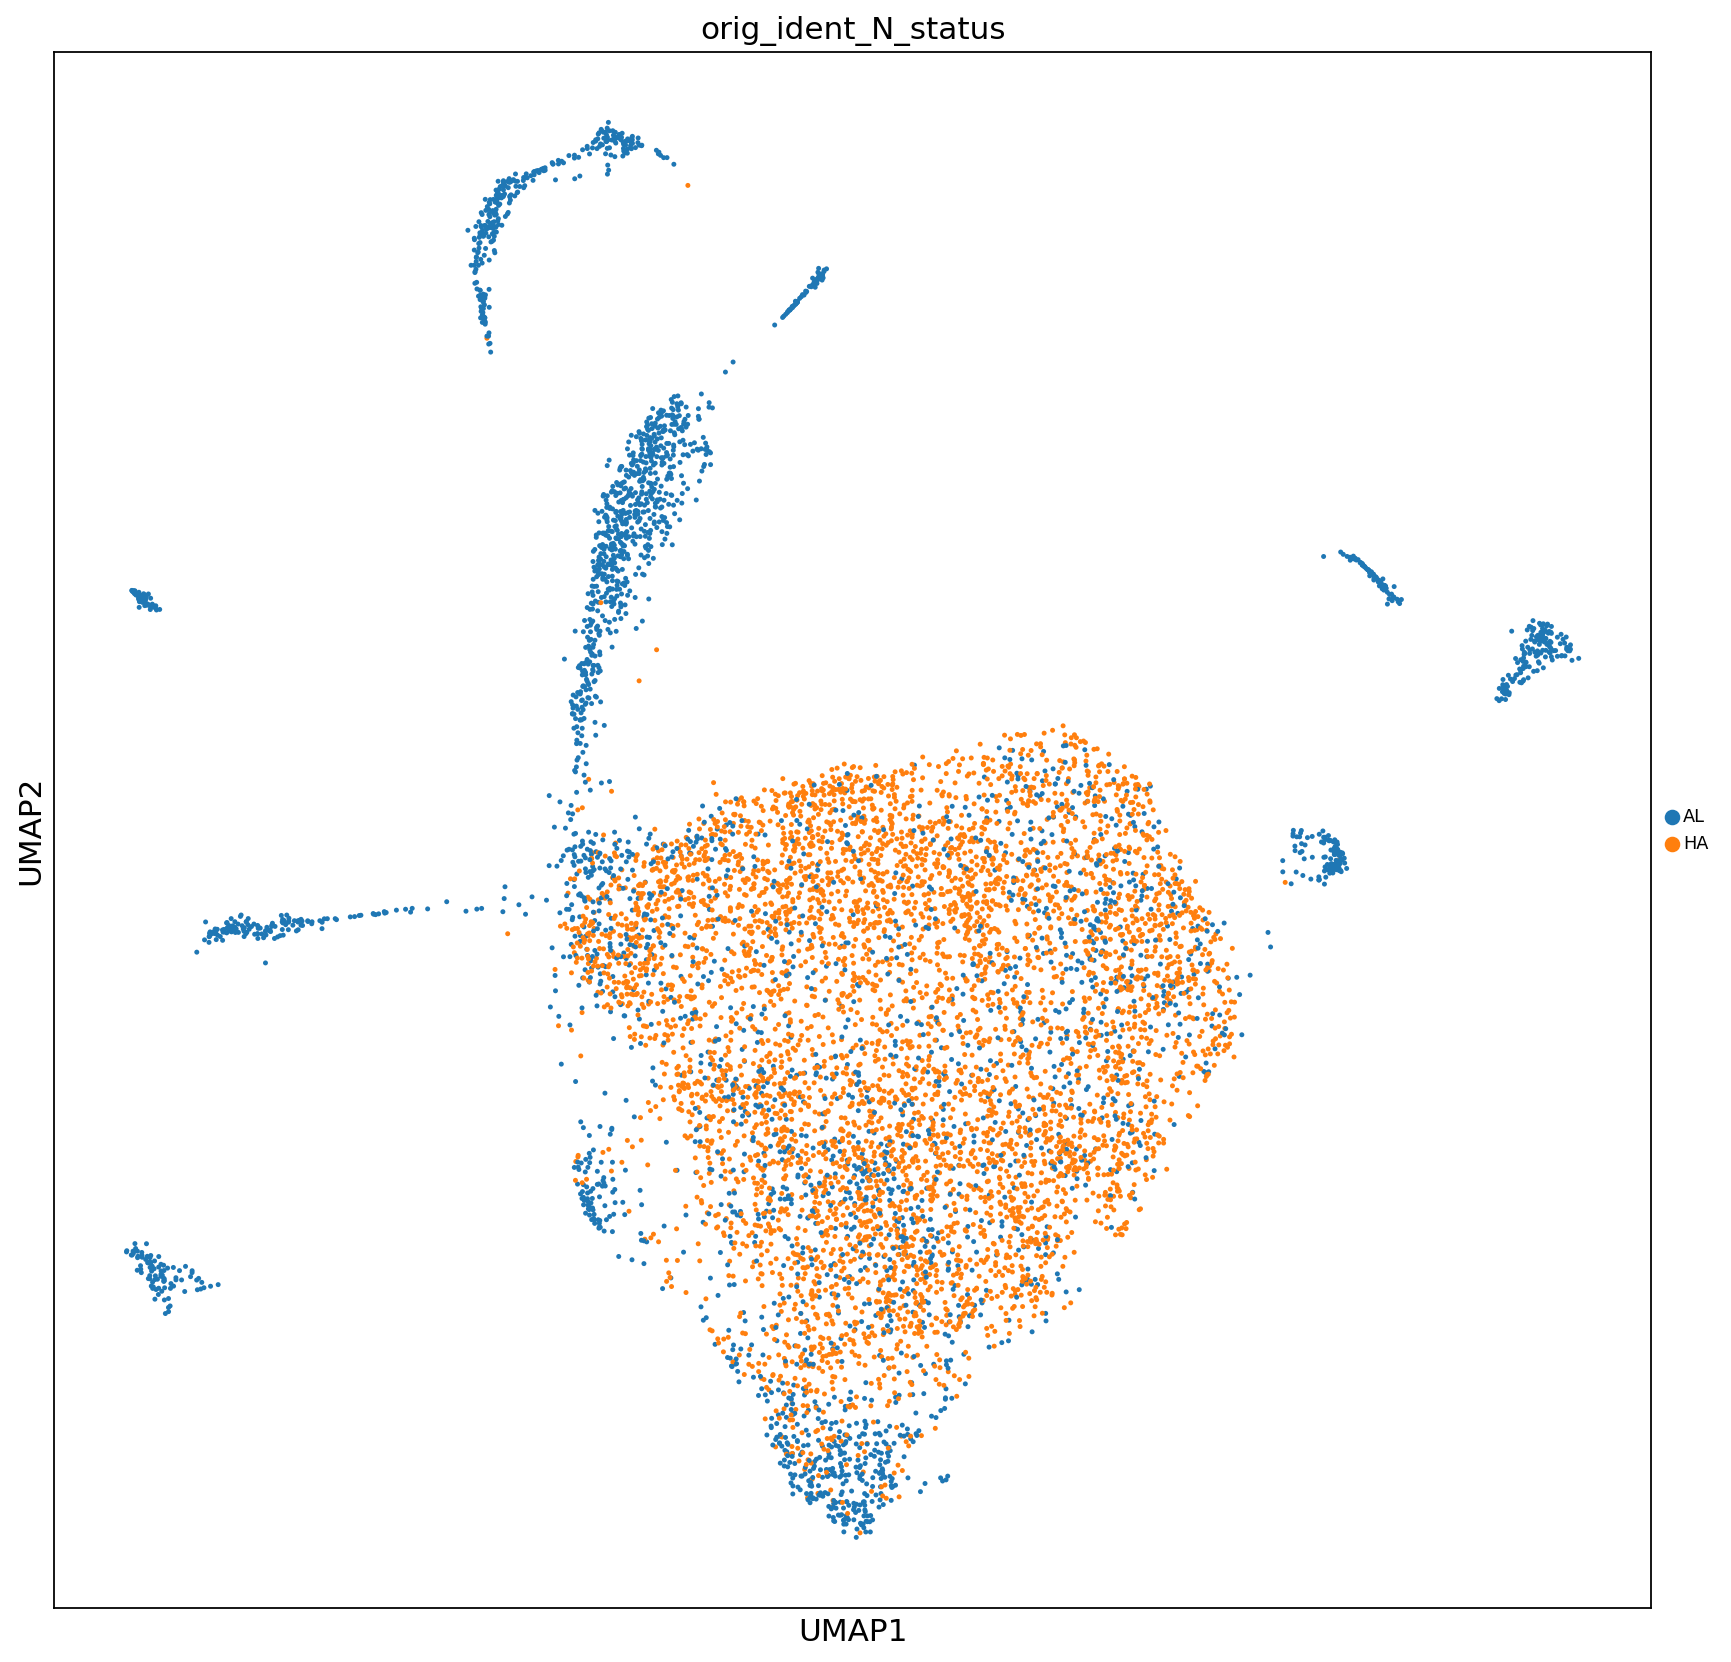

In [24]:
import pandas as pd
import numpy as np

# Classify by whether orig.ident starts with "N"
adata.obs["orig_ident_N_status"] = np.where(
    adata.obs["donor_id_global"].astype(str).str.startswith("H"),
    "HA",   # Yes, starts with N
    "AL"    # No, does not start with N
)

# Force category order so AL = default blue, HA = default orange
adata.obs["orig_ident_N_status"] = pd.Categorical(
    adata.obs["orig_ident_N_status"],
    categories=["AL", "HA"],
    ordered=True
)

sc.pl.umap(
    adata,
    color=["orig_ident_N_status"],
    palette=["#1f77b4", "#ff7f0e"],  # default matplotlib blue/orange
    show=False,
    legend_loc="right margin",
    legend_fontsize=8,
    size=20,
    wspace=0.3,
)

HD_AL_clone_status
HD_pooled        5109
AL_clonal        1820
NaN              1108
AL_polyclonal     752
Name: count, dtype: int64


/home/miniconda3/envs/cassiopeia/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


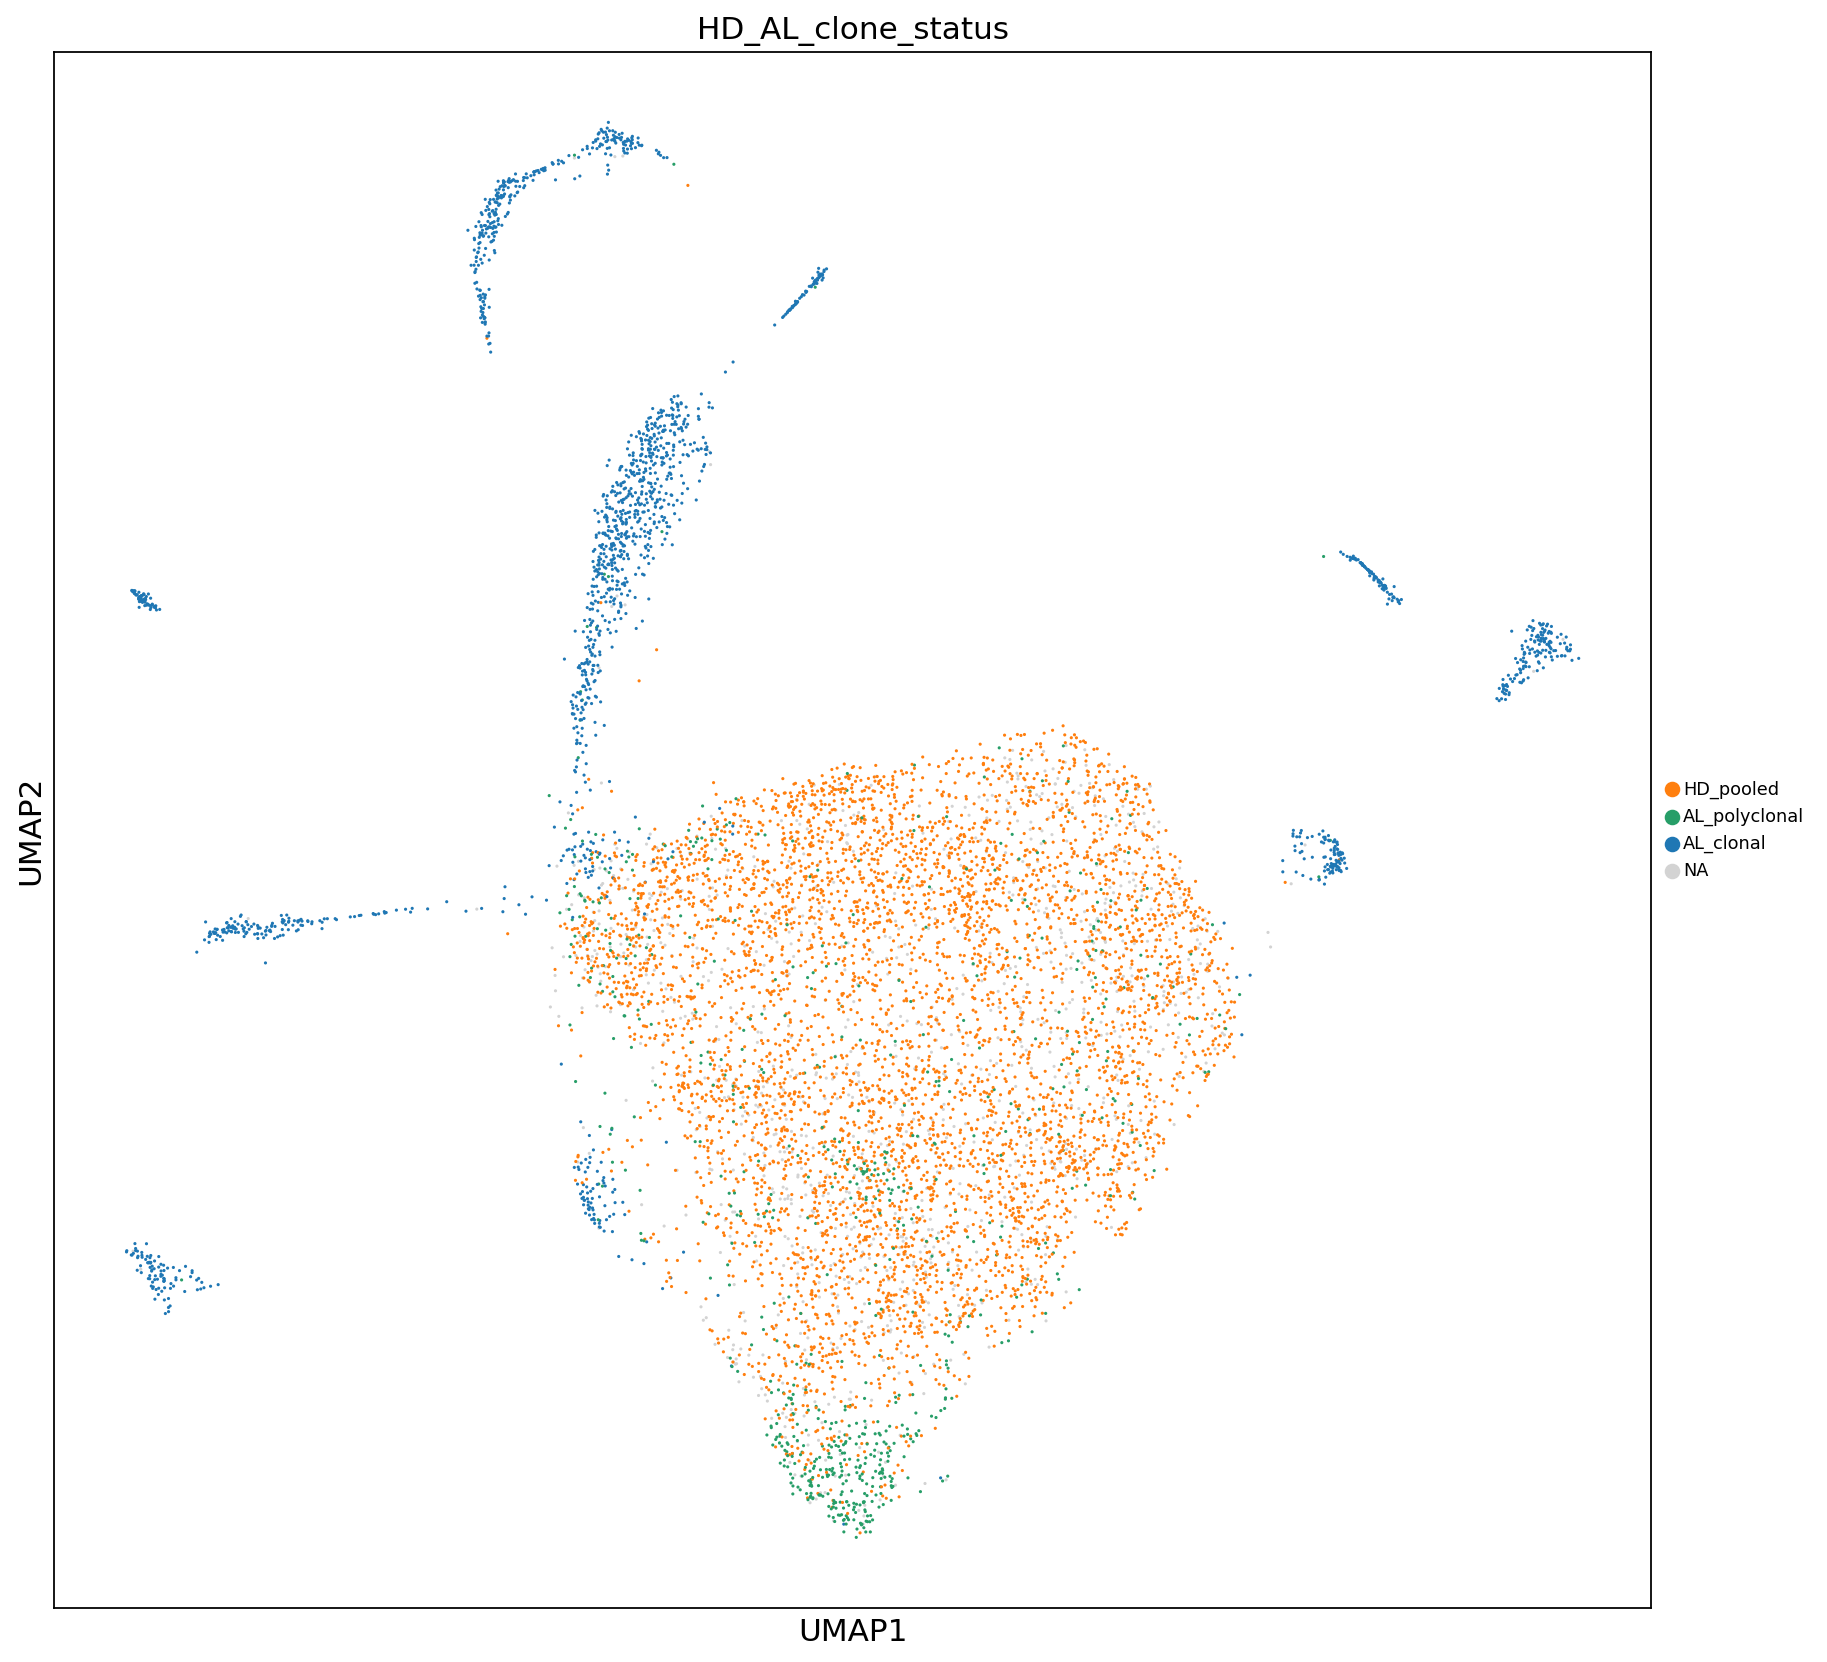


Sample-level counts:
HD_AL_clone_status
AL_polyclonal    9
AL_clonal        9
HD_pooled        8
Name: count, dtype: int64

Global sample-level test:
Kruskal-Wallis, p=0.0001

Pairwise sample-level tests:


,group1,group2,n1,n2,mean1,mean2,median1,median2,p_value,p_adj_BH
0,HD_pooled,AL_polyclonal,8,9,0.408490,0.467677,0.400429,0.464555,0.092719,0.092719
1,HD_pooled,AL_clonal,8,9,0.408490,0.107697,0.400429,0.071373,0.000082,0.000247
2,AL_polyclonal,AL_clonal,9,9,0.467677,0.107697,0.464555,0.071373,0.000412,0.000618


/tmp/ipykernel_1464625/509804951.py:229: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


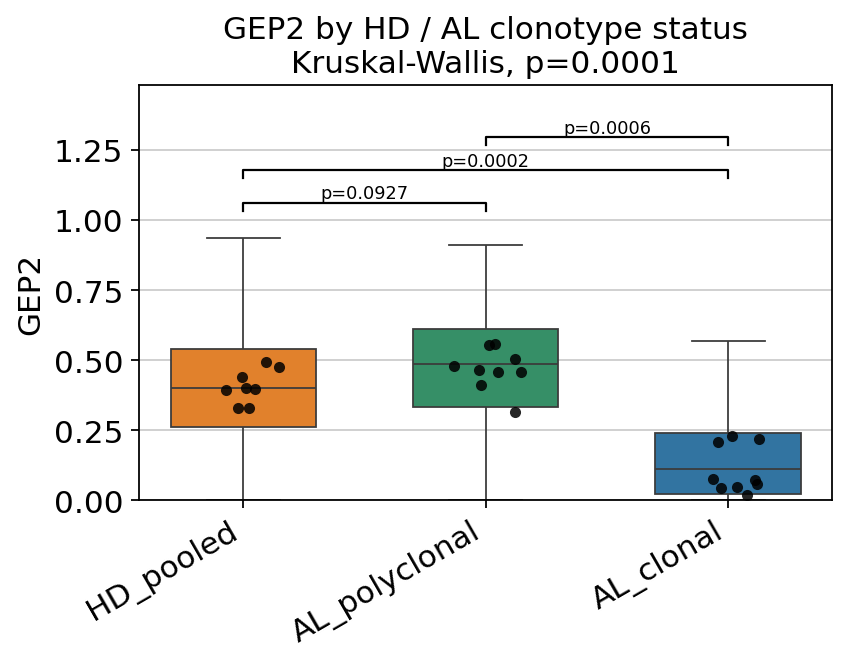

In [31]:
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from itertools import combinations

# ============================================================
# Settings
# ============================================================
score_col = "GEP2"
donor_col = "donor_id_global"
clonotype_col = "clonotype"
group_col = "HD_AL_clone_status"

# Desired order
order = ["HD_pooled", "AL_polyclonal", "AL_clonal"]

# Python default colors:
# C0 = blue, C1 = orange, C2 = green
palette = {
    "AL_clonal": "C0",      # default blue
    "HD_pooled": "C1",      # default orange
    "AL_polyclonal": "C2",  # default green
}

# ============================================================
# Helper functions
# ============================================================
def bh_adjust(pvals):
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    order_idx = np.argsort(pvals)
    ranked = pvals[order_idx]

    adjusted = ranked * n / (np.arange(n) + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    adjusted = np.clip(adjusted, 0, 1)

    out = np.empty(n)
    out[order_idx] = adjusted
    return out


def format_p(p):
    if p < 1e-4:
        return f"p={p:.1e}"
    else:
        return f"p={p:.4f}"


def add_stat_annotation(ax, x1, x2, y, h, text):
    ax.plot(
        [x1, x1, x2, x2],
        [y, y + h, y + h, y],
        lw=1,
        color="black"
    )
    ax.text(
        (x1 + x2) / 2,
        y + h,
        text,
        ha="center",
        va="bottom",
        fontsize=8,
        color="black"
    )


# ============================================================
# Check columns
# ============================================================
if donor_col not in adata.obs.columns:
    print(f"{donor_col} not found. Using orig.ident instead.")
    donor_col = "orig.ident"

if clonotype_col not in adata.obs.columns:
    raise ValueError(f"{clonotype_col} is not found in adata.obs.")

# ============================================================
# 1) Define pooled HD / AL clonal / AL polyclonal groups
# ============================================================
donor_str = adata.obs[donor_col].astype(str)
clonotype_str = adata.obs[clonotype_col].astype(str)

is_hd = donor_str.str.upper().str.startswith("HD")
is_al = donor_str.str.upper().str.startswith("AL")

is_poly = clonotype_str.str.lower().isin([
    "polyclonal",
    "poly",
    "non-clonal",
    "nonclonal",
    "nan",
    "none",
    ""
])

adata.obs[group_col] = np.nan

adata.obs.loc[is_hd, group_col] = "HD_pooled"
adata.obs.loc[is_al & is_poly, group_col] = "AL_polyclonal"
adata.obs.loc[is_al & ~is_poly, group_col] = "AL_clonal"

adata.obs[group_col] = pd.Categorical(
    adata.obs[group_col],
    categories=order,
    ordered=True
)

# Force Scanpy UMAP colors to match the boxplot
adata.uns[f"{group_col}_colors"] = [palette[g] for g in order]

print(adata.obs[group_col].value_counts(dropna=False))

# ============================================================
# 2) UMAP colored by this new grouping
# ============================================================
sc.pl.umap(
    adata,
    color=[group_col],
    show=False,
    legend_loc="right margin",
    legend_fontsize=8,
    size=8,
    wspace=0.3,
)

plt.savefig(f"UMAP_{group_col}.pdf", bbox_inches="tight")
plt.show()

# ============================================================
# 3) Prepare plotting data
# ============================================================
df = adata.obs[[score_col, group_col, donor_col]].copy()
df[score_col] = pd.to_numeric(df[score_col], errors="coerce")
df = df.dropna(subset=[score_col, group_col])

plot_order = [
    g for g in order
    if g in df[group_col].astype(str).unique()
]

plot_palette = {
    g: palette[g]
    for g in plot_order
}

# Sample-level mean GEP2
sample_df = (
    df.groupby([donor_col, group_col], observed=True, as_index=False)[score_col]
    .mean()
    .rename(columns={score_col: f"{score_col}_sample_mean"})
)

print("\nSample-level counts:")
print(sample_df[group_col].value_counts())

# ============================================================
# 4) Statistical tests on sample-level means
# ============================================================
stat_col = f"{score_col}_sample_mean"

# Global test
if len(plot_order) == 2:
    g1, g2 = plot_order
    x = sample_df.loc[sample_df[group_col] == g1, stat_col]
    y = sample_df.loc[sample_df[group_col] == g2, stat_col]

    global_test = stats.mannwhitneyu(x, y, alternative="two-sided")
    global_p = global_test.pvalue
    global_label = f"Mann-Whitney U, {format_p(global_p)}"

else:
    arrays = [
        sample_df.loc[sample_df[group_col] == g, stat_col]
        for g in plot_order
    ]

    global_test = stats.kruskal(*arrays)
    global_p = global_test.pvalue
    global_label = f"Kruskal-Wallis, {format_p(global_p)}"

print("\nGlobal sample-level test:")
print(global_label)

# Pairwise tests
pairwise_results = []

for g1, g2 in combinations(plot_order, 2):
    x = sample_df.loc[sample_df[group_col] == g1, stat_col]
    y = sample_df.loc[sample_df[group_col] == g2, stat_col]

    test = stats.mannwhitneyu(x, y, alternative="two-sided")

    pairwise_results.append({
        "group1": g1,
        "group2": g2,
        "n1": len(x),
        "n2": len(y),
        "mean1": x.mean(),
        "mean2": y.mean(),
        "median1": x.median(),
        "median2": y.median(),
        "p_value": test.pvalue
    })

pairwise_df = pd.DataFrame(pairwise_results)

if len(pairwise_df) > 0:
    pairwise_df["p_adj_BH"] = bh_adjust(pairwise_df["p_value"].values)

print("\nPairwise sample-level tests:")
display(pairwise_df)

pairwise_df.to_csv(
    f"{score_col}_{group_col}_sample_level_pairwise_stats.csv",
    index=False
)

# ============================================================
# 5) Boxplot of cell-level GEP2 + sample-level mean points
# ============================================================
plt.figure(figsize=(5.4, 4.4))
ax = plt.gca()

sns.boxplot(
    data=df,
    x=group_col,
    y=score_col,
    order=plot_order,
    palette=plot_palette,
    showfliers=False,
    width=0.6,
    linewidth=0.8,
    ax=ax
)

sns.stripplot(
    data=sample_df,
    x=group_col,
    y=stat_col,
    order=plot_order,
    color="black",
    size=5,
    jitter=0.15,
    alpha=0.85,
    ax=ax
)

plt.xlabel("")
plt.ylabel(score_col)
plt.title(f"{score_col} by HD / AL clonotype status\n{global_label}")
plt.xticks(rotation=30, ha="right")

# ============================================================
# 6) Add pairwise adjusted p-value annotations
# ============================================================
if len(pairwise_df) > 0:
    ymin = df[score_col].min()
    ymax = df[score_col].max()
    yrange = ymax - ymin

    if yrange == 0:
        yrange = 1

    base_y = ymax + 0.06 * yrange
    h = 0.03 * yrange
    step = 0.12 * yrange

    for i, row in pairwise_df.iterrows():
        g1 = row["group1"]
        g2 = row["group2"]

        x1 = plot_order.index(g1)
        x2 = plot_order.index(g2)

        y = base_y + i * step
        text = format_p(row["p_adj_BH"])

        add_stat_annotation(ax, x1, x2, y, h, text)

    ax.set_ylim(ymin, base_y + len(pairwise_df) * step + 0.1 * yrange)

plt.tight_layout()

plt.savefig(f"{score_col}_boxplot_{group_col}_with_stats.pdf", bbox_inches="tight")
plt.savefig(f"{score_col}_boxplot_{group_col}_with_stats.png", dpi=300, bbox_inches="tight")
plt.show()